In [1]:
import pandas as pd
import numpy as np
import ast
import re
import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path

FIG_DIR = Path("../docs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 220,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


## 1. Load and Parse the Corpus
Read the CSV, inspect the raw list-encoded fields, and convert conversations into Python lists.

In [2]:
df = pd.read_csv("../data/codemix_nura_task.csv")
print("Shape:", df.shape)
print("Columns:", list(df.columns))

Shape: (50, 17)
Columns: ['Unnamed: 0', 'text', 'relationship_type', 'relationship_duration', 'interlocutor_age', 'interlocutor_gender', 'share_info_self', 'share_emotions_self', 'share_info_other', 'share_emotions_other', 'feel_supported', 'trust_with_secrets', 'quality_time_freq', 'they_know_me_well', 'comfort_sharing_thoughts', 'final_message_list', 'final_speaker_tracking']


In [3]:
raw = df["final_message_list"][0]
print("Type:", type(raw))
print("First 100 chars:", raw[:100])

Type: <class 'str'>
First 100 chars: ['just let me be-', 'Wow I’m glad we r preparing for dis like professionals', 'ya if we cant be prof


In [4]:
def str_to_list(x):
    v = ast.literal_eval(x)
    return v if isinstance(v, list) else []

df["messages"] = df["final_message_list"].apply(str_to_list)
df["speakers"] = df["final_speaker_tracking"].apply(str_to_list)

print("Type now:", type(df["messages"][0]))
print("Number of messages in convo 0:", len(df["messages"][0]))
print("First 3 messages:", df["messages"][0][:3])

Type now: <class 'list'>
Number of messages in convo 0: 21
First 3 messages: ['just let me be-', 'Wow I’m glad we r preparing for dis like professionals', 'ya if we cant be professionals']


## 2. Corpus Integrity
Check whether the message, speaker, and metadata fields are reliable enough for downstream annotation.

In [5]:
# Do messages and speakers line up in each conversation?
for i in range(len(df)):
    n_msg = len(df["messages"][i])
    n_spk = len(df["speakers"][i])
    if n_msg != n_spk:
        print(f"Convo {i}: {n_msg} messages but {n_spk} speakers  <-- mismatch")

Convo 12: 18 messages but 0 speakers  <-- mismatch
Convo 13: 32 messages but 0 speakers  <-- mismatch
Convo 14: 10 messages but 0 speakers  <-- mismatch
Convo 15: 38 messages but 0 speakers  <-- mismatch
Convo 17: 25 messages but 0 speakers  <-- mismatch
Convo 18: 16 messages but 0 speakers  <-- mismatch
Convo 19: 21 messages but 0 speakers  <-- mismatch
Convo 20: 19 messages but 0 speakers  <-- mismatch
Convo 26: 60 messages but 0 speakers  <-- mismatch
Convo 30: 540 messages but 0 speakers  <-- mismatch
Convo 32: 500 messages but 0 speakers  <-- mismatch
Convo 36: 1 messages but 0 speakers  <-- mismatch
Convo 37: 2 messages but 0 speakers  <-- mismatch
Convo 38: 2 messages but 0 speakers  <-- mismatch
Convo 39: 117 messages but 0 speakers  <-- mismatch
Convo 42: 5 messages but 0 speakers  <-- mismatch
Convo 43: 7 messages but 0 speakers  <-- mismatch
Convo 44: 7 messages but 0 speakers  <-- mismatch
Convo 48: 39 messages but 0 speakers  <-- mismatch
Convo 49: 41 messages but 0 speake

In [6]:
# quantify the speaker-tracking failure
empty = [i for i in range(len(df)) if len(df["speakers"][i]) == 0]
has_speakers = len(df) - len(empty)

print(f"Conversations with missing speaker data: {len(empty)}/{len(df)}")
print(f"Conversations usable for speaker-dependent annotation: {has_speakers}")

Conversations with missing speaker data: 20/50
Conversations usable for speaker-dependent annotation: 30


In [7]:
UNATTRIBUTED_LABELS = {"unknown", "in reply to this message"}
all_spk_vals = [s for spklist in df["speakers"] for s in spklist]
unattributed = sum(1 for s in all_spk_vals if s.strip().lower() in UNATTRIBUTED_LABELS)
print(f"Unattributed speaker slots: {unattributed}/{len(all_spk_vals)} "
      f"({unattributed/len(all_spk_vals):.1%})")

Unattributed speaker slots: 1416/4983 (28.4%)


## 3. Message and Conversation Shape
Summarize how compact the conversations are, then compute pipeline-tokenized lengths.

In [8]:
def words(s):
    return re.findall(r"[A-Za-z']+", str(s).lower())

In [9]:
import sys
sys.path.insert(0, "..")
from codemix_task.common import tokenize, SG_TERMS

In [10]:
# Flatten all messages across all conversations
all_msgs = [m for convo in df["messages"] for m in convo]

# Three distributions
turns_per_convo = [len(convo) for convo in df["messages"]]
words_per_msg   = [len(words(m)) for m in all_msgs]
chars_per_msg   = [len(str(m)) for m in all_msgs]

In [11]:
print(f"Total messages: {len(all_msgs)}")
print(f"Turns/convo:   mean {np.mean(turns_per_convo):.1f}  median {np.median(turns_per_convo):.0f}  max {max(turns_per_convo)}")
print(f"Words/message: mean {np.mean(words_per_msg):.1f}  median {np.median(words_per_msg):.0f}  max {max(words_per_msg)}")
print(f"Chars/message: mean {np.mean(chars_per_msg):.1f}  median {np.median(chars_per_msg):.0f}  max {max(chars_per_msg)}")

Total messages: 6483
Turns/convo:   mean 129.7  median 54  max 554
Words/message: mean 5.1  median 4  max 62
Chars/message: mean 24.9  median 19  max 302


In [12]:
# Token length using the annotation pipeline tokenizer (includes punctuation/digits/CJK as tokens)
pipeline_lens = [len(tokenize(m)) for m in all_msgs]
print(f"Pipeline tokens/message: mean {np.mean(pipeline_lens):.1f}  "
      f"median {np.median(pipeline_lens):.0f}  max {max(pipeline_lens)}")

Pipeline tokens/message: mean 5.6  median 5  max 59


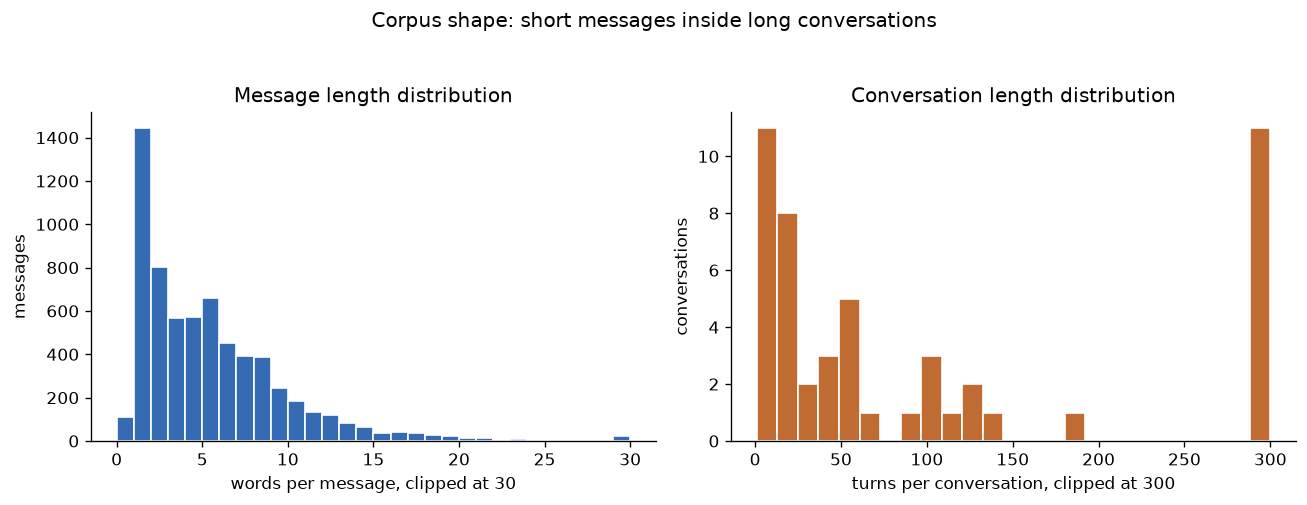

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].hist(np.clip(words_per_msg, 0, 30), bins=30, color="#356bb3", edgecolor="white")
ax[0].set_title("Message length distribution")
ax[0].set_xlabel("words per message, clipped at 30")
ax[0].set_ylabel("messages")

ax[1].hist(np.clip(turns_per_convo, 0, 300), bins=25, color="#bf6b31", edgecolor="white")
ax[1].set_title("Conversation length distribution")
ax[1].set_xlabel("turns per conversation, clipped at 300")
ax[1].set_ylabel("conversations")

fig.suptitle("Corpus shape: short messages inside long conversations", y=1.04)
plt.tight_layout()
fig.savefig(FIG_DIR / "message_and_conversation_shape.png", bbox_inches="tight")
plt.show()


## 4. Language Signals
Inspect Singlish particles, informal English, emoji, Chinese script, and affective/offensive terms.

### 4.1 Singlish Discourse Particles

In [14]:
all_tokens = []
for m in all_msgs:
    all_tokens += words(m)
token_counts = Counter(all_tokens)

# candidate Singlish particles (a hypothesis — we inspect, then decide)
candidates = ["lah","leh","lor","meh","sia","hor","bah","mah","liao",
              "aiya","haiya","paiseh","walao","wah","siao","liddat","sian"]

print("Singlish particle candidates found in corpus:")
found = [(p, token_counts[p]) for p in candidates if token_counts[p] > 0]
found.sort(key=lambda x: -x[1])
for p, c in found:
    print(f"  {p:10s} {c}")
print(f"\nSG total (these candidates): {sum(c for _,c in found)}")

Singlish particle candidates found in corpus:
  sia        40
  wah        26
  lah        21
  leh        18
  lor        9
  bah        9
  paiseh     7
  meh        4
  hor        4
  walao      4
  sian       4
  mah        3
  liao       3
  aiya       3
  siao       2
  liddat     2
  haiya      1

SG total (these candidates): 160


In [15]:
# singlish particle counts using the pipeline tokenizer + SG_TERMS
sg_counts = Counter()
for m in all_msgs:
    for t in tokenize(m):
        tl = t.lower()
        if tl in SG_TERMS:
            sg_counts[tl] += 1

print("Top Singlish particles (pipeline tokenizer):")
for p, c in sg_counts.most_common(5):
    print(f"  {p:10s} {c}")

Top Singlish particles (pipeline tokenizer):
  ah         104
  sia        40
  wah        26
  lah        21
  leh        18


### 4.2 Informal English Short Forms

In [16]:
abbr = ["u","ur","idk","alr","tmr","r","tgt","cos","sch","rmb","wat","lmk",
        "gna","ngl","j","oso","bc","uk","dun","nvr","otw","dat","wtv","yk",
        "msg","idw","btr","dis","prolly","smthing","tq","cus","anyw","imo","wad"]

found_abbr = [(a, token_counts[a]) for a in abbr if token_counts[a] > 0]
found_abbr.sort(key=lambda x: -x[1])
for a, c in found_abbr[:20]:
    print(f"  {a:10s} {c}")
print(f"\nInformal-English total: {sum(c for _,c in found_abbr)}")
print(f"'u' alone: {token_counts['u']} (rank in corpus: ", 
      sorted(token_counts.values(), reverse=True).index(token_counts['u'])+1, ")")

  u          491
  ur         87
  idk        66
  alr        51
  tmr        43
  r          41
  tgt        32
  cos        30
  sch        17
  rmb        16
  wat        14
  lmk        14
  gna        11
  ngl        10
  j          9
  oso        9
  bc         9
  uk         8
  dun        7
  nvr        6

Informal-English total: 1008
'u' alone: 491 (rank in corpus:  4 )


### 4.3 Lexical, Emoji, and Affective Profile

In [17]:
print("Top 20 tokens:")
for w, c in token_counts.most_common(20):
    print(f"  {w:8s} {c}")

# Emoji scan
emoji = Counter()
for m in all_msgs:
    for ch in str(m):
        if ord(ch) > 0x2190:   # rough cutoff above normal text/punctuation
            emoji[ch] += 1

print("\nTop emoji:")
for e, c in emoji.most_common(10):
    print(f"  {e}  {c}")
print(f"Total emoji-ish: {sum(emoji.values())}")

Top 20 tokens:
  i        1563
  to       718
  the      694
  u        491
  it       364
  a        359
  in       349
  is       320
  for      314
  but      314
  person   288
  can      285
  and      282
  like     278
  oh       276
  so       254
  just     243
  not      235
  my       234
  this     232

Top emoji:
  😭  56
  🤣  31
  ❤  27
  🥲  20
  💚  18
  🙏  13
  🙂  12
  ️  12
  🤡  10
  😀  10
Total emoji-ish: 422


In [18]:
# potentially-offensive token scan to establish hate speech is near-absent
offensive = ["wtf","shit","damn","fuck","fucking","crap","hell","stupid",
             "idiot","dumb","bitch","sucks","pissed","annoying","mad","lame","ass"]
found_off = [(a, token_counts[a]) for a in offensive if token_counts[a] > 0]
found_off.sort(key=lambda x: -x[1])
for a, c in found_off:
    print(f"  {a:10s} {c}")
total_off = sum(c for _,c in found_off)
print(f"\nOffensive-ish total: {total_off}/ {len(all_tokens)} ({total_off/len(all_tokens):.2%} of all tokens)")

  shit       32
  damn       28
  wtf        24
  fuck       9
  annoying   9
  fucking    7
  ass        6
  hell       5
  stupid     4
  mad        4
  dumb       3
  sucks      3
  pissed     3
  idiot      2
  bitch      2
  lame       2

Offensive-ish total: 143/ 33059 (0.43% of all tokens)


In [19]:
# message-level offensive lexicon scan using the pipeline tokenizer
REPORT_OFFENSIVE_TERMS = {
    "shit", "wtf", "fuck", "fucking", "damn", "crap", "useless", "stupid",
    "idiot", "dumb", "bitch", "pissed",
}

def has_offensive(m):
    return any(t.lower() in REPORT_OFFENSIVE_TERMS for t in tokenize(m))

off_msgs = [m for m in all_msgs if has_offensive(m)]
print(f"Messages with offensive-lexicon token: {len(off_msgs)}/{len(all_msgs)} ({len(off_msgs)/len(all_msgs):.1%})")

Messages with offensive-lexicon token: 115/6483 (1.8%)


In [20]:
# Messages with Chinese script
zh_msgs = [m for m in all_msgs if re.search(r"[\u4e00-\u9fff]", str(m))]
print(f"Messages with Chinese script: {len(zh_msgs)}/{len(all_msgs)} ({len(zh_msgs)/len(all_msgs):.1%})")

Messages with Chinese script: 8/6483 (0.1%)


In [21]:
# presennce of Malay, Hokkien, Tamil (romanised) tokens
malay = ["makan","tak","nak","boleh","sudah","alamak","macam","sedap","jalan",
         "kena","balik","tolong","jangan","pergi","sikit","banyak","lepak",
         "aku","kau","apa","siapa","mana","bisa"]
hokkien = ["sibei","jialat","buay","kaypoh","angmoh","chiong","heng","suay",
           "jio","zhun","sui","lim","kiam","bojio","atas","shiok"]
tamil_roman = ["macha","machan","dei","poda","semma","vanakkam","thambi","aiyo"]

for name, lex in [("Malay", malay), ("Hokkien (romanised)", hokkien),
                  ("Tamil (romanised)", tamil_roman)]:
    found = [(w, token_counts[w]) for w in lex if token_counts[w] > 0]
    found.sort(key=lambda x: -x[1])
    print(f"{name}: {sum(c for _, c in found)} token hits")
    for w, c in found:
        print(f"  {w:10s} {c}")

tamil_script_msgs = [m for m in all_msgs if re.search(r"[஀-௿]", str(m))]
print(f"\nMessages with Tamil script: {len(tamil_script_msgs)}/{len(all_msgs)}")

Malay: 8 token hits
  makan      4
  kena       2
  balik      1
  apa        1
Hokkien (romanised): 13 token hits
  heng       7
  shiok      3
  suay       2
  jialat     1
Tamil (romanised): 4 token hits
  aiyo       4

Messages with Tamil script: 0/6483


In [22]:
# presence of romanised Mandarin pinyin tokens
pinyin_words = ["nihao","xiexie","weisheme","zenme","mingtian","zuotian",
                "xianzai","keyi","meiyou","buyao","wanan","zaijian",
                "gongxi","pengyou","laoshi","dongxi","jiayou"]
found_py = [(w, token_counts[w]) for w in pinyin_words if token_counts[w] > 0]
print("Single-token pinyin hits:", found_py if found_py else "none")

pinyin_bigrams = [r"\bni hao\b", r"\bxie xie\b", r"\bjia you\b", r"\bwan an\b",
                  r"\bzai jian\b", r"\bbu yao\b", r"\bmei you\b"]
bigram_hits = [(pat, str(m)[:60]) for pat in pinyin_bigrams
               for m in all_msgs if re.search(pat, str(m).lower())]
print("Pinyin bigram hits:", bigram_hits if bigram_hits else "none")

Single-token pinyin hits: none
Pinyin bigram hits: none


In [23]:
# non eng offensive
hokkien_vulgar = ["knn","knnbccb","ccb","cb","lj","kns","cheebye","chibai",
                  "lanjiao","kanina","kani","sibei"]
malay_offensive = ["bodoh","sial","siol","celaka","babi","pukimak","bangang","gila"]

for name, lex in [("Hokkien vulgarities", hokkien_vulgar),
                  ("Malay offensive-ish", malay_offensive)]:
    found = [(w, token_counts[w]) for w in lex if token_counts[w] > 0]
    found.sort(key=lambda x: -x[1])
    print(f"{name}: {sum(c for _, c in found)} token hits")
    for w, c in found:
        ex = next(m for m in all_msgs if w in words(m))
        print(f"  {w:8s} {c}   e.g. {str(ex)[:60]!r}")

Hokkien vulgarities: 2 token hits
  knn      1   e.g. 'KNN'
  cb       1   e.g. 'aiya cb will take some time to exclude u out'
Malay offensive-ish: 0 token hits


In [24]:
abbr_set = set(abbr)

def message_has_sg(m):
    return any(t.lower() in SG_TERMS for t in tokenize(m))

def message_has_abbr(m):
    return any(t.lower() in abbr_set for t in tokenize(m))

def message_has_emoji(m):
    return any(ord(ch) > 0x2190 for ch in str(m))

signal_counts = pd.Series({
    "Singlish particle": sum(message_has_sg(m) for m in all_msgs),
    "Informal English": sum(message_has_abbr(m) for m in all_msgs),
    "Emoji / symbol": sum(message_has_emoji(m) for m in all_msgs),
    "Chinese script": len(zh_msgs),
    "Offensive lexicon": len(off_msgs),
}).sort_values()

signal_pct = signal_counts / len(all_msgs) * 100

fig, ax = plt.subplots(figsize=(8, 4.6))
ax.barh(signal_pct.index, signal_pct.values, color=["#5b8c5a", "#4f81bd", "#c27c39", "#8064a2", "#b85450"])
ax.set_xlabel("messages containing signal (%)")
ax.set_title("Message-level prevalence of annotation-relevant signals")
for i, (pct, count) in enumerate(zip(signal_pct.values, signal_counts.values)):
    ax.text(pct + 0.25, i, f"{pct:.1f}% ({count})", va="center", fontsize=9)
ax.set_xlim(0, max(signal_pct.values) + 8)
plt.tight_layout()
fig.savefig(FIG_DIR / "language_signal_prevalence.png", bbox_inches="tight")
plt.show()


In [25]:
top_sg = pd.Series(dict(sg_counts.most_common(8))).sort_values()
off_counts = pd.Series({term: token_counts[term] for term in REPORT_OFFENSIVE_TERMS if token_counts[term] > 0}).sort_values().tail(8)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))

ax[0].barh(top_sg.index, top_sg.values, color="#4f81bd")
ax[0].set_title("Top Singlish particles")
ax[0].set_xlabel("token count")
for i, value in enumerate(top_sg.values):
    ax[0].text(value + 0.2, i, str(value), va="center", fontsize=9)

ax[1].barh(off_counts.index, off_counts.values, color="#b85450")
ax[1].set_title("Top offensive-lexicon tokens")
ax[1].set_xlabel("token count")
for i, value in enumerate(off_counts.values):
    ax[1].text(value + 0.2, i, str(value), va="center", fontsize=9)

fig.suptitle("Lexical cues behind the language-ID and harm schemes", y=1.03)
plt.tight_layout()
fig.savefig(FIG_DIR / "top_language_harm_terms.png", bbox_inches="tight")
plt.show()


## 5. Relationship and Intimacy Metadata

In [26]:
# relationship type distribution
print(df["relationship_type"].value_counts().to_string())

# Intimacy / trust scales (1-5)
print()
for col in ["trust_with_secrets", "feel_supported", "comfort_sharing_thoughts"]:
    print(f"{col}: mean {df[col].mean():.2f}")

relationship_type
Close - Close friend                 29
Social - Good friend/acquaintance    13
Work - Colleague                      2
Education - Classmate                 2
Close - Romantic partner/spouse       2
Other: my sister                      1
Other: Brother                        1

trust_with_secrets: mean 3.88
feel_supported: mean 3.88
comfort_sharing_thoughts: mean 4.14
